# Copula Modeling
## Theoretical Distributions
When modelling risky financial assets, the prices are often assumed to be lognormal. While this is a reasonable model, it tends to underestimate the probabilities and impacts of unlikely events, as it has lighter tails than returns exhibit in reality. Consider, instead, modelling the log-returns of the assets with a probability distribution that has heavier tails, like the $t$-distribution with $\nu$ degrees of freedom. $t$-distributions with lower degrees of freedom have heavier tails, and as $ν ⟶ ∞$, the $t_\nu$-distribution approaches the $N(0,1)$-distribution.

One way to describe the correlation of two assets, without making any assumptions about their distributions, is calculating their Kendall's Tau. For the two random variables $X_1$ and $X_2$, Kendall's Tau can be defined as

$$τ(X_1, X_2) = 𝔼(\mathrm{sgn}((X_1-X_1^´)(X_2-X_2^´)))$$

where $X_1^´$ and $X_2^´$ are independent copies of $X_1$ and $X_2$. If we assume that this relation between the pairs of assets is the same for all pairs, we can write

$$τ(X_i, X_j) = τ \quad i \neq j$$

With this, we can express the value of the portfolio of these assets as

$$V_T =  ∑\limits_{i=1}^N V_{i,0} e^{X_i}$$

As each asset's log-return has a marginal $t$ distribution with $\nu$ degrees of freedom, mean $\mu$ and scale factor $σ$, we can rewrite the log-returns as

$$\mu + \sigma \sqrt{\frac{\nu-2}{\nu}}* t_\nu$$

While this models how each asset behaves on its own, it does not describe the joint distribution of the assets. This is the role of the copula, which models the joint distribution of the assets. Central to the use of copulas is the probability transform: for any random variable $X_i$ with a continuous distribution function $F_i$, $F_i(X_i)$ is distributed as $U(0,1)$. By writing $U_i = F_i(X_i)$, we can write $X$ as $X=(F_1^{-1}(U_1), ..., F_N^{-1}(U_N))$, from which we can construct the copula:

$$C(u_1, ..., u_N) = P(U_1 \leq u_1, ..., U_N \leq u_N)$$

In this project, we will model three different copulas, with different tail dependencies: the Gaussian copula, the $t$-copula, and the Clayton copula (a type of Archimedean copula).

### Copula 1: Gaussian

The Gaussian copula corresponds to a multivariate Gaussian (Normal) distribution with correlation matrix $R$, and is given by

$$C_{R}(u_1,\ldots,u_d) = \Phi_{R}^{d}\left(\Phi^{-1}(u_1),\ldots,\Phi^{-1}(u_d)\right)$$

where $\Phi^{-1}$ is the inverse of the standard normal distribution function and $\Phi_{R}^{d}$ is the $d$-variate normal distribution function with correlation matrix $R$. Therefore, to model the $N$ assets, we need to determine the correlation matrix $R$. For the Gaussian copula, it can be shown that the linear correlation coefficient between two variables is given by

$$\rho_{ij} = \sin\Big(\frac{\pi\tau(X_i, X_j)}{2}\Big)$$

As we have assumed that the Kendall's tau is the same for all pairs of assets, it holds, for all pairs of assets, that

$$\rho = \sin\Big(\frac{\pi\tau}{2}\Big)$$

Since all pairs of assets have this correlation, and all assets have correlation $1$ to itself, the correlation matrix $R$ can be expressed as

$$
R =
\begin{pmatrix}
1 & \rho & \cdots & \rho\\
\rho & 1 & \ddots & \vdots\\
\vdots & \ddots & \ddots & \rho\\
\rho & \cdots & \rho & 1
\end{pmatrix}
$$



Using this, we can now model the outcomes of the final values $V_T$ of the portfolio using the Gaussian copula for the joint distribution of the assets.


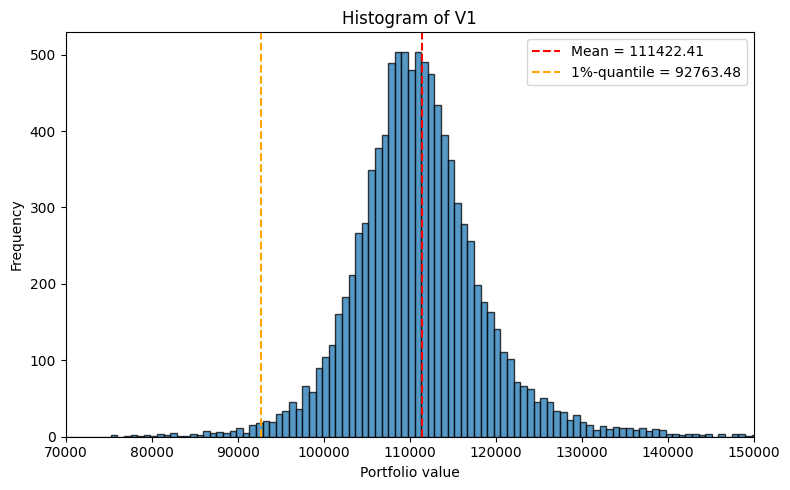

In [1]:
import numpy as np
from scipy.stats import t, norm
import matplotlib.pyplot as plt

# ---- PARAMETERS ----
seed = 1
n_assets = 100
mu = 0.1
df = 3
std = 0.1
tau = 0.4
n = 10_000
investment_per_asset = 1_000
V0 = n_assets * investment_per_asset

t_std = np.sqrt(df / (df - 2)) # std of t(df) with scale = 1
scale = std / t_std

np.random.seed(seed)

def gaussian_copula(n_sim = n):
    rho = np.sin(np.pi * tau / 2)
    R = np.full((n_assets, n_assets), rho)
    np.fill_diagonal(R, 1.0)

    L = np.linalg.cholesky(R)
    Z = L @ np.random.randn(n_assets, n_sim) # @ is matrix multiplication
    U = norm.cdf(Z)
    returns = t.ppf(U, df=df) * scale + mu
    V1 = investment_per_asset * np.sum(np.exp(returns), axis=0)

    return V1

def plot_histogram_V1(V1, copula):
    quantile_1p = np.percentile(V1, 1)
    plt.figure(figsize=(8,5))
    if copula == "gaussian":
      plt.hist(V1, bins=2500, alpha=0.75, edgecolor='black')
    if copula == "t":
      plt.hist(V1, bins=300, alpha=0.75, edgecolor='black')
    if copula == "clayton":
      plt.hist(V1, bins=1500, alpha=0.75, edgecolor='black')
    if copula == "single_gaussian":
      plt.hist(V1, bins=1000, alpha=0.75, edgecolor='black')
    if copula == "single_t":
      plt.hist(V1, bins=500, alpha=0.75, edgecolor='black')
    if copula == "single_clayton":
      plt.hist(V1, bins=500, alpha=0.75, edgecolor='black')
    plt.axvline(np.mean(V1), color='red', linestyle='--', label=f'Mean = {np.mean(V1):.2f}')
    plt.axvline(quantile_1p, color='orange', linestyle='--', label=f'1%-quantile = {quantile_1p:.2f}')
    plt.xlabel("Portfolio value")
    plt.ylabel("Frequency")
    plt.title("Histogram of V1")
    plt.xlim(70_000, 150_000)
    plt.tight_layout()
    plt.legend()
    plt.show()

V1_gaussian = gaussian_copula()
plot_histogram_V1(V1_gaussian, "gaussian")

In the histogram above, we see that the distribution of portfolio values does not seem to be skewed either positively or negatively. Further, as the Gaussian copula has no tail dependence, the tails of the distribution of portfolio values are comparatively light.

### Copula 2: $t_ν$
As for the Gaussian copula, the linear correlation coefficient for a pair of random variables with a multivariate $t_\nu$-distribution can be expressed as

$$\rho = \sin\Big(\frac{\pi\tau}{2}\Big)$$

The $t_\nu$ copula is, similarly to the Gaussian copula, given by

$$C_{\nu, R}(u_1,\ldots,u_d) = t_{\nu,R}^{d}\left(t_\nu^{-1}(u_1),\ldots,t_\nu^{-1}(u_d)\right)$$

where $t_\nu^{-1}$ is the inverse of the standard $t$-distribution function with $\nu$ degrees of freedom, and $t_{\nu,R}^{d}$ is the $d$-variate $t$ distribution function with correlation matrix $R$ and $\nu$ degrees of freedom, with $R$ defined in the same way as for the Gaussian copula.

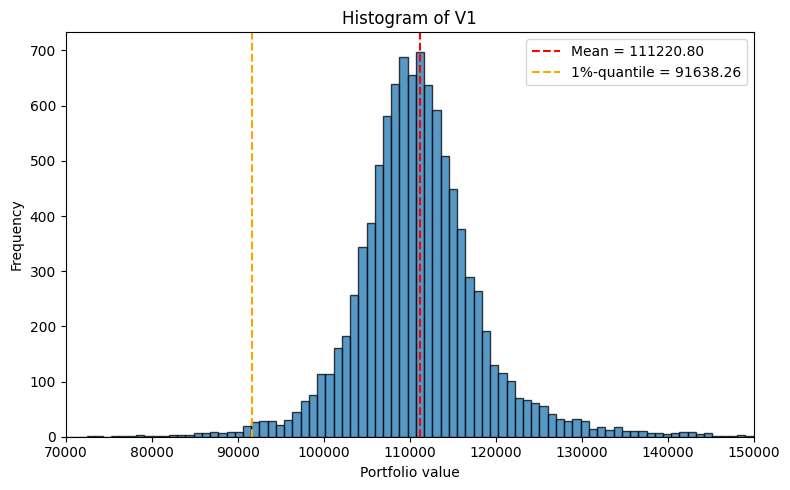

In [2]:
np.random.seed(seed)
def t_copula(df_copula=4, n_sim = n):
    rho = np.sin(np.pi * tau / 2)
    R = np.full((n_assets, n_assets), rho)
    np.fill_diagonal(R, 1.0)

    L = np.linalg.cholesky(R)
    Y = np.random.randn(n_assets, n_sim)        # N(0, I)
    W = np.random.chisquare(df_copula, n_sim)   # chi-square
    Z = (L @ Y) / np.sqrt(W / df_copula)        # multivariate t(df_copula)

    U = t.cdf(Z, df=df_copula)
    returns = t.ppf(U, df=df) * scale + mu

    V1 = investment_per_asset * np.sum(np.exp(returns), axis=0)

    return V1

V1_t = t_copula()
plot_histogram_V1(V1_t, "t")

As for the Gaussian copula, the histogram of portfolio values does not seem to be skewed for the $t$-distribution either, but in contrast to the Gaussian copula, the $t$-copula has tail dependence, both positive and negative, which contributes to the fatter tails in this case, compared to the Gaussian copula. The lower value of the $1\%$-quantile in the $t$-copula above also shows this.

### Copula 3: Clayton
We now turn to the Clayton copula, which is a type of Archimedean copula. Archimedean copulas have the form

$$C(u_1,\ldots,u_d) = \Psi\left( \Psi^{-1}(u_1) + \cdots + \Psi^{-1}(u_d) \right)$$

If we take $\Psi(t)$ to be the Laplace Transform $\Psi(t) = 𝔼(e^{-tX})$ of $X$, and $X$ to be $\mathrm{Gamma}(\frac{1}{\theta}, 1)$-distributed, then the Archimedean copula is known at the Clayton copula. In this case, it can be shown that

$$\Psi(t) = (t+1)^{-\frac{1}{\theta}}$$

so the inverse is

$$\Psi^{-1}(t) = t^{-\theta} -1$$

From this, we can express the Clayton copula as

$$C(u_1,\ldots,u_d) = \left( u_1^{-\theta} + \cdots + u_d^{-\theta} - d + 1 \right)^{-1/\theta}$$

The parameter $\theta$ remains to be calculated. Using the values of Kendall's Tau, we can calculate the value of $\theta$ as

$$\theta = \frac{2\tau}{1-\tau}$$



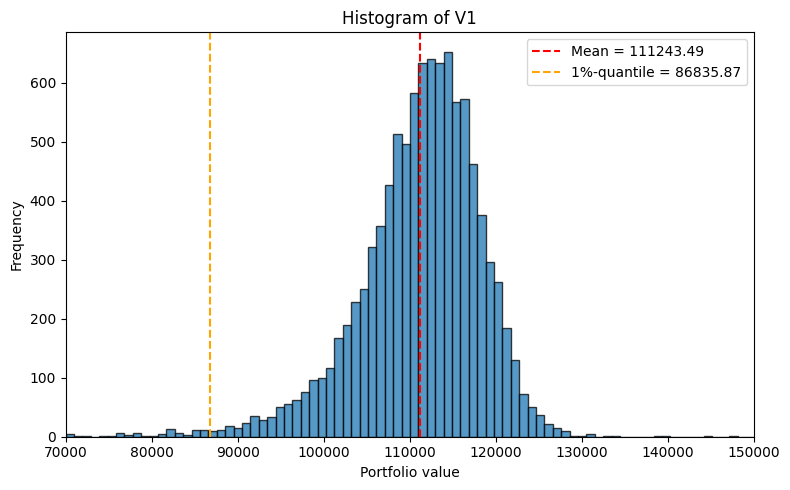

In [3]:
np.random.seed(seed)
def clayton_copula(n_sim = n):
    theta = 2 * tau / (1 - tau)
    W = np.random.gamma(shape=1/theta, scale=1, size=n_sim)  # size n_sim
    E = np.random.exponential(scale=1.0, size=(n_assets, n_sim))

    U = (1 + E / W) ** (-1/theta)
    returns = t.ppf(U, df=df) * scale + mu

    V1 = investment_per_asset * np.sum(np.exp(returns), axis=0)

    return V1

V1_clayton = clayton_copula()
plot_histogram_V1(V1_clayton, "clayton")


In contrast to the Gaussian and $t$-copulas, we see that the Clayton copula is negatively skewed, and has a heavy left tail, but light right tail. The Clayton copula has a lower tail dependence, but no upper tail dependence, which explains why the left tail is heavy, but the right tail is not. The lower value of the $1\%$-quantile, compared both to the Gaussian and $t$-copula also shows this.

## Empirical Distributions
Now, let us apply the findings to returns of real-world assets. Let us consider three stock indices from around the world: FTSE 100 ("^FTSE") in England, S&P 500 ("^GSPC") in the US, and OMX Stockholm ("^OMX") in Sweden. To determine what copula to use to describe the dependence structure between these three assets, we begin by determining their marginal distributions, and then test different copulas.

[*********************100%***********************]  3 of 3 completed


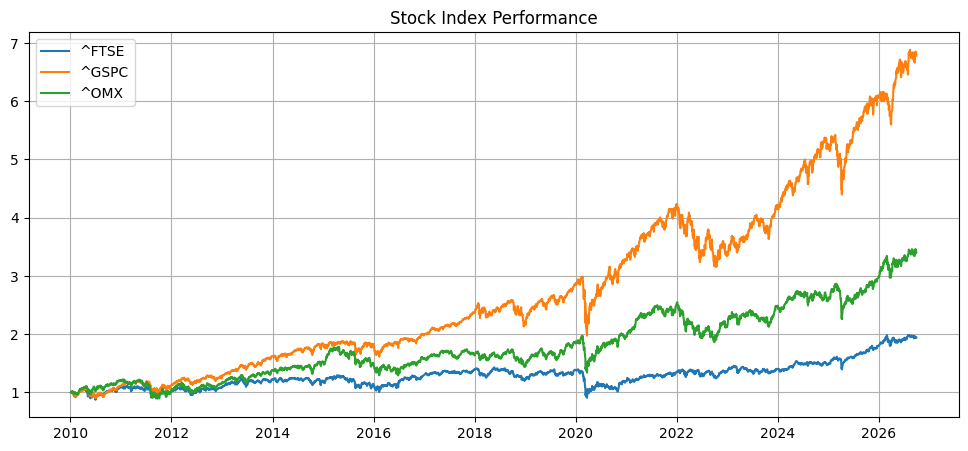

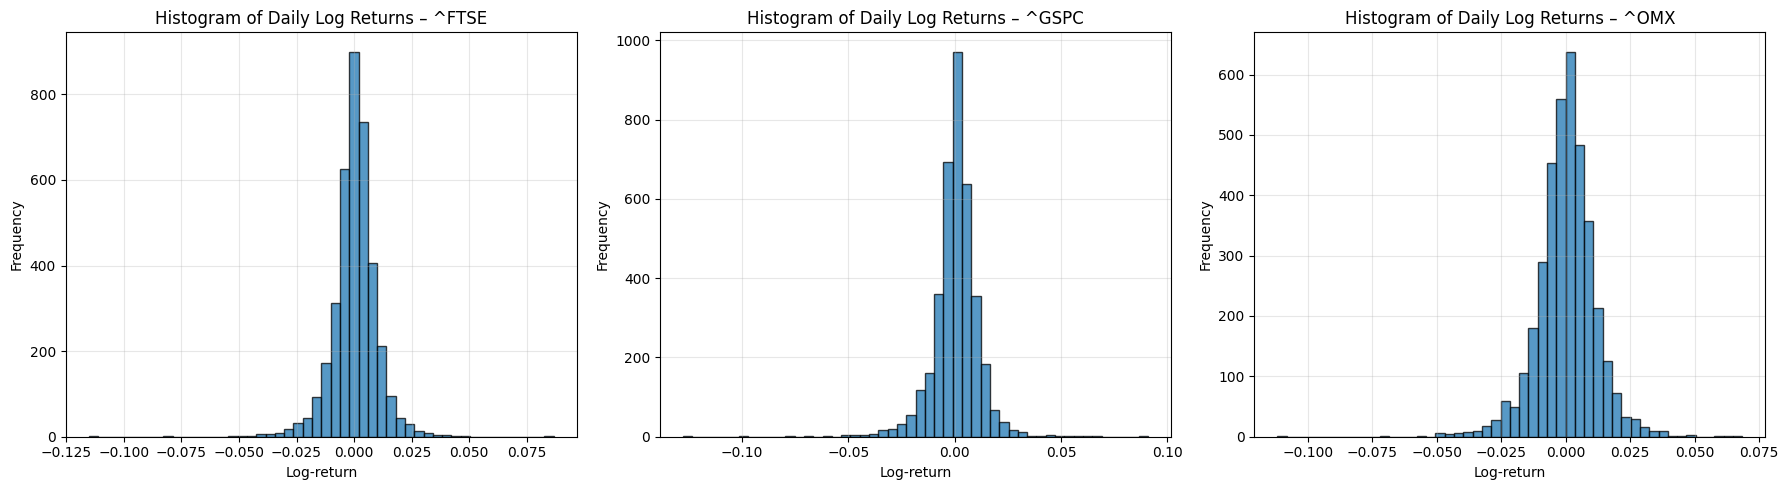

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def get_returns():
  tickers = ["^FTSE", "^GSPC", "^OMX"]   #FTSE100, S&P500, OMX Stockholm
  data = yf.download(tickers, start="2010-01-01", auto_adjust=True)["Close"]
  prices = data.dropna()
  returns = np.log(data).diff().dropna()
  return prices, returns

def plot_indices(prices):
  plt.figure(figsize=(12, 5))
  normalized = prices / prices.iloc[0]
  for col in normalized.columns:
      plt.plot(normalized.index, normalized[col], label=col)
  plt.title("Stock Index Performance")
  plt.legend()
  plt.grid(True)
  plt.show()

def plot_returns_histograms(returns):
  fig, axes = plt.subplots(1, 3, figsize=(18, 5))
  for ax, col in zip(axes, returns.columns):
      ax.hist(returns[col], bins=50, alpha=0.75, edgecolor = "black")
      ax.set_title(f"Histogram of Daily Log Returns – {col}")
      ax.set_xlabel("Log-return")
      ax.set_ylabel("Frequency")
      ax.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.show()


prices, returns = get_returns()
plot_indices(prices)
plot_returns_histograms(returns)

We now turn to the marginal distributions of each index's daily log-return, shown in the three histograms above. The returns seem to be somewhat symmetrically distributed around a mean, and all three indices show several values very far away from the mean, suggesting heavy tails, both lower and upper.
### Marginal Distributions

Based on this, we will compare two models for the marginal distributions of these assets: the normal distribution and the $t$-distribution. While the normal distribution is perhaps the most common model for log-returns, it has been criticised for underestimating the probability of large outliers, and hence has too light tails. The $t$-distribution, on the other hand, has heavier tails, and like the normal distribution, is symmetrical around the mean. To compare these two distributions, then, we will fit a normal and a $t$-distribution to each index, and optimize the parameters of each distribution (the mean, $\mu$, and the scale factor, $\sigma$, for the normal and $t$-distribution, and the degrees of freedom $\nu$ for the $t$-distribution).

To determine which distribution is the better fit for these empirical returns of the three indices, we calculate the Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC). These are calculated as follows:

$$\mathrm{AIC} = 2k - 2 \ln(L)$$

$$\mathrm{BIC} = k\ln(n) - 2 \ln(L)$$

where $n$ is the number of datapoints, $L$ is the maximal value of the  likelihood-function, and $k$ is the number of parameters in the model: 2 ($\mu$ and $σ$) for the normal distribution, and 3 ($\mu$, $σ$ and $\nu$) for the $t$-distribution. The optimal choice of the parameters is that which yields the highest value of $L$, so for both these criteria, a lower value is better. Based on this, we compare the normal and $t$-distributions in terms of AIC and BIC, and proceed with the marginal distributions that are the best in these terms.

In [5]:
import numpy as np
from scipy.stats import norm, t

def fit_marginals_AIC_BIC(returns_df):
    results = []
    for col in returns_df.columns:
        x = returns_df[col].values
        n = len(x)

        # -------- Normal fit --------
        mu_norm, sigma_norm = norm.fit(x)
        logL_norm = np.sum(norm.logpdf(x, loc=mu_norm, scale=sigma_norm))
        k_norm = 2  # 2 parameters: mu, sigma
        AIC_norm = 2*k_norm - 2*logL_norm
        BIC_norm = k_norm*np.log(n) - 2*logL_norm

        # -------- Student-t fit --------
        df_t, mu_t, sigma_t = t.fit(x)
        logL_t = np.sum(t.logpdf(x, df=df_t, loc=mu_t, scale=sigma_t))
        k_t = 3  # 3 parameters: df, mu, sigma
        AIC_t = 2*k_t - 2*logL_t
        BIC_t = k_t*np.log(n) - 2*logL_t

        # -------- Store results --------
        results.append({
            "Index": col,
            "Normal AIC": AIC_norm,
            "t AIC": AIC_t,
            "Normal BIC": BIC_norm,
            "t BIC": BIC_t,
            "t df": df_t,
            "t mu": mu_t,
            "t sigma": sigma_t,
            "Normal mu": mu_norm,
            "Normal sigma": sigma_norm})

    results_df = pd.DataFrame(results)
    return results_df

results_df = fit_marginals_AIC_BIC(returns)
print(results_df[["Index", "Normal AIC", "t AIC", "Normal BIC", "t BIC"]])

   Index    Normal AIC         t AIC    Normal BIC         t BIC
0  ^FTSE -24288.161548 -25080.694510 -24275.687119 -25061.982866
1  ^GSPC -23379.424183 -24520.734763 -23366.949754 -24502.023119
2   ^OMX -23009.561394 -23488.942917 -22997.086964 -23470.231273


For each of the three indices, we see that the AIC and BIC are lower for the $t$-distribution than the normal distribution, suggesting the $t$-distribution models these log-returns better than the normal distribution, which is in line with what is expected theoretically. Hence, we will proceed to model the marginal distributions of each index's log-returns as t-distributed, with the optimal values of $\mu$, $σ$ and $\nu$, which are displayed below.

In [6]:
print(results_df[["Index", "t mu", "t sigma", "t df"]])

   Index      t mu   t sigma      t df
0  ^FTSE  0.000468  0.006308  3.234439
1  ^GSPC  0.000926  0.006419  2.776085
2   ^OMX  0.000578  0.008311  4.002658


We can note that the average return $\mu$ is the highest for the S&P 500 ("^GSPC"), and the lowest for the FTSE 100 ("^FTSE"), which we also see in the graph of the stock indices above. We also note that the S&P 500 has the fewest degrees of freedom $\nu$, indicating that it has the heaviest tails of the three indices, which seems reasonable given the histograms of log-returns of the three assets. The scale parameter $\sigma$ is the highest for OMX Stockholm ("^OMX"), which also seems reasonable, given the histograms.

In order to assess the choice of the $t$-distribution for the marginal distribution of the three indices, we can also evaluate the quantile-quantile plot (Q-Q plot) of the indices.

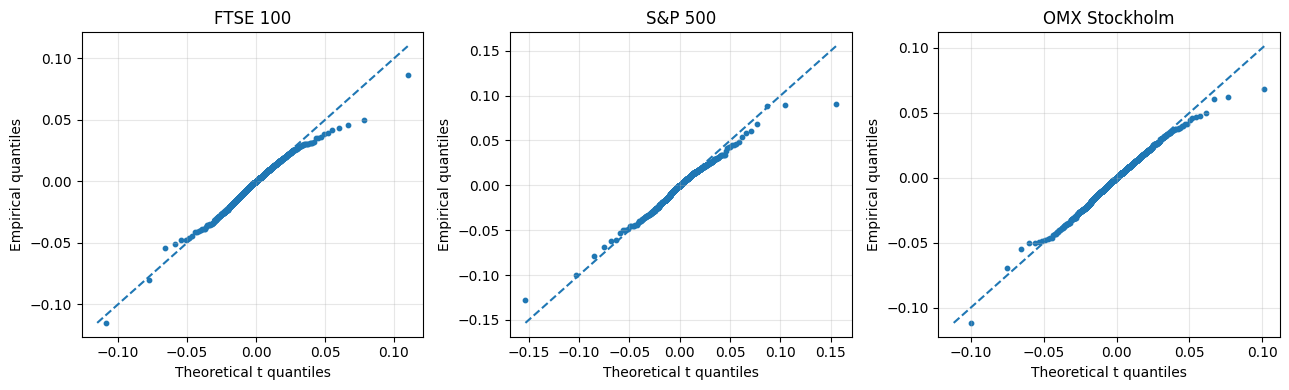

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t


def plot_t_qq(results_df, returns):
    tickers = ["^FTSE", "^GSPC", "^OMX"]
    names = ["FTSE 100", "S&P 500", "OMX Stockholm"]

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    for i, (ticker, name) in enumerate(zip(tickers, names)):

        # Observed returns
        data = returns[ticker].dropna().values
        data = np.sort(data)

        # Fitted t parameters
        mu = results_df["t mu"].iloc[i]
        sigma = results_df["t sigma"].iloc[i]
        df = results_df["t df"].iloc[i]

        # Theoretical quantiles
        probabilities = (np.arange(1, len(data) + 1) - 0.5) / len(data)
        theoretical_quantiles = t.ppf(probabilities, df=df, loc=mu, scale=sigma)

        # QQ plot
        axes[i].scatter(theoretical_quantiles, data, s=10)

        # 45-degree reference line
        lower = min(theoretical_quantiles.min(), data.min())
        upper = max(theoretical_quantiles.max(), data.max())

        axes[i].plot([lower, upper], [lower, upper], linestyle="--")

        axes[i].set_title(name)
        axes[i].set_xlabel("Theoretical t quantiles")
        axes[i].set_ylabel("Empirical quantiles")
        axes[i].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_t_qq(results_df, returns)

In the Q-Q plots above, we see that the empirical quantiles of the three stock indices line up relatively well with the theoretical quantiles of the $t$-distribution, indicating that the $t$-distribution well models the empirical marginal distributions of the three indices. We see that on the bottom left of the three Q-Q plots, the empirical quantiles are close to the theoretical quantiles, showing that the $t$-distribution models the left tail well. However, for all three indices, in the top right of the plots, the empirical quantiles fall below the line indicating the expected empirical quantiles. This means that the $t$-distribution expects more extreme positive values than what is observed, so the empirical distribution has a lighter right tail than $t$-distribution used in this model. However, as this project is mainly concerned with the downside risk of a portfolio that invests in these indices, it is more important that the left tail is modelled well, so the model having a too heavy right tail is not a very big problem in this case.

### Copula Choice

We now compare the three copulas considered above - Gaussian, $t$, and Clayton - and investigate which one fits the empirical distribution of returns the best. To do this, we calculate the log-likelihood-function $\ell$ for each copula.

For the Gaussian copula (the multivariate normal distribution), it is given by

$$\ell(R)
= -\frac{n}{2}\ln(\det(R))
-\frac{1}{2}\sum_{i=1}^n
\left(
z_i^\top R^{-1} z_i - \sum_{j=1}^d z_{ij}^2
\right)$$

where $R$ is the correlation matrix, and $z_{ij} = \Phi^{-1}(u_{ij})$ for $i \in [0, n]$ where $n$ is the number of observations (daily log-returns), and $j \in [0, d]$ where $d$ is the dimension of the copula. In this case, $d=3$, as we have $3$ indices.

For the $t$-copula, the log-likelihood function is given by

$$\ell(\Sigma, \nu)
=
\sum_{i=1}^n
\left[
\ln (t_d(x_i \mid \Sigma, \nu))
-
\sum_{j=1}^d \ln (t_1(x_{ij} \mid \nu))
\right]$$

where

$$t_d(x_i \mid \Sigma,\nu)
=
\frac{
\Gamma\!\left(\frac{\nu+d}{2}\right)
}{
\Gamma\!\left(\frac{\nu}{2}\right)
(\nu \pi)^{d/2}
|\Sigma|^{1/2}
}
\left(
1 + \frac{1}{\nu} x_i^\top \Sigma^{-1} x_i
\right)^{-(\nu+d)/2}$$

where $x_{ij} = t_{\nu}^{-1}(u_{ij})$, and $i,j$ as above.

For the Clayton copula, the log-likelihood is given by

$$
\ell(\theta) = \sum_{i=1}^n \log\!\left[(\theta+1)^{\,d-1}\prod_{j=1}^d u_{ij}^{-(1+\theta)} \left(\sum_{j=1}^d u_{ij}^{-\theta} - d + 1\right)^{-\left(d+\frac{1}{\theta}\right)}\right]
$$

### Tail Dependence

One of the most important characteristics of each copula is their upper and lower tail dependences. For two random variables $X$ and $Y$, their lower tail dependence is defined as

$$
\lambda_L(X, Y)
=
\lim_{u \rightarrow 0^+}
\mathbb{P}\left(
F_X(X) \le u
\mid
F_Y(Y) \le u
\right)
$$

Similarly, the upper tail dependence is defined as

$$
\lambda_U(X, Y)
=
\lim_{u \rightarrow 1^-}
\mathbb{P}\left(
F_X(X) > u
\mid
F_Y(Y) > u
\right)
$$

For the Gaussian copula, it holds that

$$
\lambda_L(X, Y) = \lambda_U(X, Y) = 0
$$

For the $t_{\nu}$-copula, where $ρ$ is the correlation coefficient between $X$ and $Y$, it holds that

$$
\lambda_L(X, Y) = \lambda_U(X, Y) =
2\, t_{\nu+1}\left(
- \sqrt{
\frac{(\nu+1)(1-\rho)}{1+\rho}
}
\right)
$$

For the Clayton copula, it holds that

$$
\lambda_L(X, Y) = 2^{-1/\theta},
\qquad
\lambda_U(X, Y) = 0
$$

Hence, the Gaussian copula has no tail dependence, the $t_{\nu}$-copula has both upper and lower tail dependence, and these are symmetrical, while the Clayton has lower tail dependence but no upper tail dependence.


In [8]:
import numpy as np
import pandas as pd
from scipy.stats import norm, t, rankdata, kendalltau
from scipy.linalg import cholesky, det, inv
from math import log
import warnings
from scipy.special import gammaln
warnings.filterwarnings("ignore")

def uniform_rvs_from_returns(returns_df):
    U = returns_df.apply(lambda col: rankdata(col) / (len(col) + 1))
    # U(0,1) variables from empirical returns
    return U.values


#                                    GAUSSIAN COPULA                           #
def gaussian_copula_loglikelihood(U):
    # Transform
    Z = norm.ppf(U)  # inverse CDF
    n, d = Z.shape
    R = np.corrcoef(Z, rowvar=False)  # sample correlation matrix
    # Ensure positive definite
    R += np.eye(d) * 1e-8
    R_inv = np.linalg.inv(R)
    sign, logdet = np.linalg.slogdet(R)
    if sign <= 0:
        raise ValueError("Non-positive-definite correlation matrix")
    # Compute log-likelihood
    const = -0.5 * n * logdet
    quad = 0.0
    I = np.eye(d)
    A = R_inv - I
    for i in range(n):
        z = Z[i, :][:, None]  # None to reduce array to a column vector
        quad += float(z.T @ A @ z)
    loglik = const - 0.5 * quad
    # number of free params in R: d(d-1)/2
    k = int(d * (d - 1) / 2)
    return loglik, k, R


#                                    t COPULA                                  #
def multivariate_t_pdf(x, Sigma, nu):
    d = Sigma.shape[0]  # dimensions of correlation matrix (d=3)
    sign, logdet = np.linalg.slogdet(Sigma)
    if sign <= 0:
        return -np.inf
    quad = float(x.T @ np.linalg.inv(Sigma) @ x)
    ln_num = gammaln((nu + d) / 2.0)
    ln_den = gammaln(nu / 2.0) + 0.5 * d * log(nu * np.pi) + 0.5 * logdet
    power = - (nu + d) / 2.0
    return np.exp(ln_num - ln_den) * (1.0 + quad / nu) ** power


def t_copula_loglikelihood(U, nu_grid=None):
    if nu_grid is None:
        nu_grid = np.concatenate((np.linspace(2.5, 7, 10), np.linspace(8, 30, 12)))

    n, d = U.shape
    best = {"nu": None, "loglik": -np.inf, "R": None}
    for nu in nu_grid:
        X = t.ppf(U, df=nu)
        R = np.corrcoef(X, rowvar=False) # depends on nu (degrees of freedom)
        # Numerical stability
        eps = 1e-8
        R += np.eye(d) * eps

        sum_logc = 0.0
        for i in range(n):
            x = X[i, :]
            # Univariate t densities (1st term)
            log_f_uni = np.sum(t.logpdf(x, df=nu))
            # Multivariate t density (2nd term)
            f_mt = multivariate_t_pdf(x, R, nu)
            log_f_mt = np.log(f_mt)
            # Copula density
            sum_logc += (log_f_mt - log_f_uni)

        # Save best result
        if sum_logc > best["loglik"]:
            best["loglik"] = sum_logc
            best["nu"] = nu
            best["R"] = R

    # Number of parameters: R correlation params + nu
    k = int(d * (d - 1) / 2) + 1

    return best["loglik"], k, best["nu"], best["R"]


#                                    CLAYTON COPULA                            #
def clayton_loglikelihood(U, theta):
    d = 3
    u1 = U[:, 0]
    u2 = U[:, 1]
    u3 = U[:, 2]

    a1 = u1 ** (-theta)
    a2 = u2 ** (-theta)
    a3 = u3 ** (-theta)

    S = a1 + a2 + a3 - d + 1.0
    prod_term = (u1 ** -(1 + theta)) * (u2 ** -(1 + theta)) * (u3 ** -(1 + theta))
    density = ((theta + 1.0) ** (d-1)) * prod_term * (S ** -(d + (1.0 / theta)))
    log_density = np.log(density)
    return np.sum(log_density)


def clayton_copula_loglikelihood(U):
    taus = []
    for i in range(3):
        for j in range(i+1, 3):
            tau, _ = kendalltau(U[:, i], U[:, j])
            taus.append(tau)
    tau_avg = np.nanmean(taus)
    theta0 = 2 * tau_avg / (1 - tau_avg) if tau_avg < 1 else 10.0
    theta0 = max(theta0, 0.1)

    # Grid search for MLE
    thetas = np.linspace(theta0 * 0.25, theta0 * 5, 50)
    best_ll = -np.inf
    best_theta = theta0

    for th in thetas:
        ll = clayton_loglikelihood(U, th)
        if ll > best_ll:
            best_ll = ll
            best_theta = th

    k = 1  # number of parameters
    return best_ll, k, best_theta



#                                   COPULA COMPARISON                          #
def compare_copulas(returns_df):
    U = uniform_rvs_from_returns(returns_df)
    n, d = U.shape

    gauss_loglik, k_g, Rg = gaussian_copula_loglikelihood(U)
    AIC_g = 2*k_g - 2*gauss_loglik
    BIC_g = k_g * np.log(n) - 2*gauss_loglik

    t_loglik, k_t, best_nu, Rt = t_copula_loglikelihood(U)
    AIC_t = 2*k_t - 2*t_loglik
    BIC_t = k_t * np.log(n) - 2*t_loglik

    clay_loglik, k_c, theta_hat = clayton_copula_loglikelihood(U)
    AIC_c = 2*k_c - 2*clay_loglik
    BIC_c = k_c * np.log(n) - 2*clay_loglik

    print("Copula fit comparison:\n")
    print(f"Gaussian copula:   AIC={AIC_g:.2f}, BIC={BIC_g:.2f}")
    print(f"t copula:          AIC={AIC_t:.2f}, BIC={BIC_t:.2f}")
    print(f"Clayton:           AIC={AIC_c:.2f}, BIC={BIC_c:.2f}")

    return {
        "gaussian": {"loglik": gauss_loglik, "k": k_g, "AIC": AIC_g, "BIC": BIC_g, "R": Rg},
        "t": {"loglik": t_loglik, "k": k_t, "AIC": AIC_t, "BIC": BIC_t, "nu": best_nu, "R": Rt},
        "clayton": {"loglik": clay_loglik, "k": k_c, "AIC": AIC_c, "BIC": BIC_c, "theta": theta_hat}}

copula_results = compare_copulas(returns)

Copula fit comparison:

Gaussian copula:   AIC=-4921.55, BIC=-4902.84
t copula:          AIC=-5274.53, BIC=-5249.58
Clayton:           AIC=-765.58, BIC=-759.34


### Copula Comparison
From the values of AIC and BIC above, we can conclude that the $t$-copula is the copula best suited to describe the dependence structure of these three indices, as it has a lower AIC and BIC than the Gaussian and the Clayton copulas. However, the comparatively high AIC and BIC of the Clayton copula warrants a comment: one of the main reasons for the higher AIC and BIC is that the Clayton copula only has one parameter in which it can be optimized, $θ$, in contrast to the three parameters in the case of the Gaussian copula (the three linear correlation coefficients), and four parameters in the case of the $t$-copula (the three correlations, and the number of degrees of freedom $\nu$). This decreases its flexibility, and prevents it from fitting well to the observed data, leading to a low value of the likelihood. However, AIC and BIC both 'reward' having fewer parameters, which compensates for this partially, as it decreases the AIC and BIC of the Clayton copula.

The fact that the $t$-copula is the best performing one is also not surprising, as it is the only of the three copulas shown here that has both upper and lower tail dependence - the Gaussian copula has neither upper nor lower tail dependence, while the Clayton copula only has lower tail dependence. In reality, we expect both upper and lower tail dependence between the indices: periods of large gains in the stock markets tend to occur at the same time, and the same goes for periods of large losses, as can be seen in the graph of stock index performance above. Hence, we will proceed with the $t$-copula to model the joint returns of these three indices.

### Value at Risk and Expected Shortfall: Empirical and Simulated Returns
Based on these marginal distributions and the dependence structure given by the $t$-copula, we can simulate the Value at Risk and Expected Shortfall of a diversified portfolio, for example one with $\frac{1}{3}$ of the money in each of the three assets, and compare the Value at Risk of this portfolio to that of a portfolio which only held one of the three indices. Despite the correlation between the assets, and the lower tail dependence, we expect a diversification effect, as the assets are not perfectly correlated, and hence a lower Value at Risk for the diversified portfolio.

Furthermore, in order to understand how well the t-copula and t-distributed marginals model the distribution of the assets' returns, we also estimate the Value at Risk and the Expected Shortfall using historical values of the returns of the three indices. If the model specified above is a good model for the joint returns of the three indices, then the simulated values of the Value at Risk and Expected Shortfall will be close to the empirical estimates of these two measures.

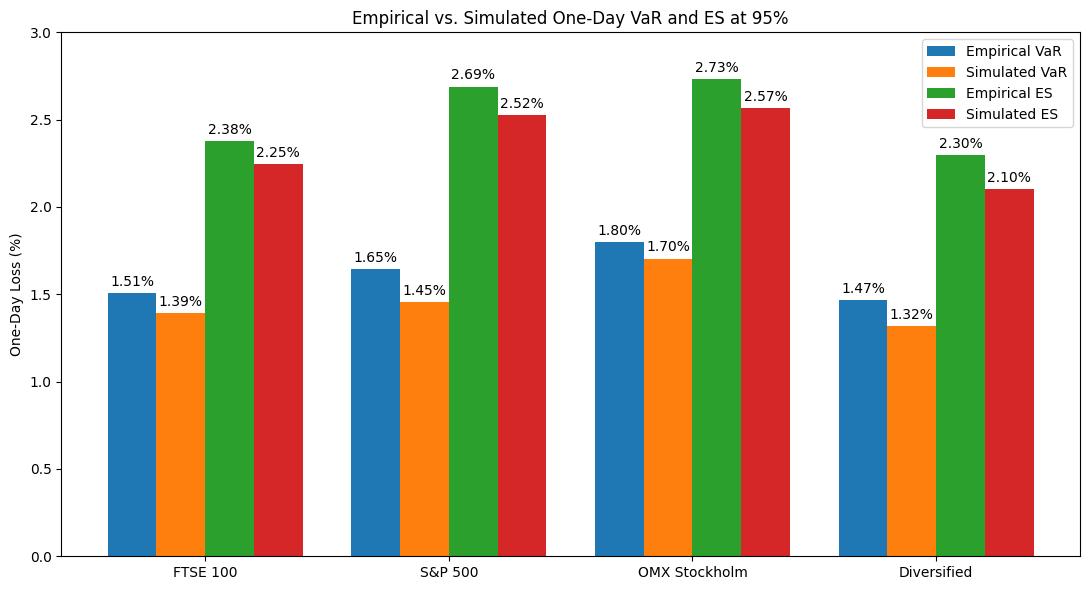

In [9]:
import numpy as np
from scipy.stats import t, multivariate_t

def empirical_VaR_ES(returns, confidence_level=0.95):
    losses = -returns
    var = losses.quantile(confidence_level)
    es = losses[losses.ge(var)].mean()
    return var, es

def simulated_VaR_ES(results_df, copula_results, confidence_level, w = None, N = 100_000):
    np.random.seed(1)
    mu = results_df["t mu"].values
    sigma = results_df["t sigma"].values
    df_marg = results_df["t df"].values
    nu = copula_results["t"]["nu"]
    R = copula_results["t"]["R"]

    if w is None:
      w = np.array([1/3, 1/3, 1/3])
    Z = multivariate_t.rvs(loc=np.zeros(3), shape=R, df=nu, size=N)
    U = t.cdf(Z, df=nu)

    # Marginal inverse CDFs
    R_sim = np.zeros_like(U)
    for i in range(3):
        R_sim[:, i] = t.ppf(U[:, i], df=df_marg[i], loc=mu[i], scale=sigma[i])
    L = -(R_sim @ w)

    VaR = np.quantile(L, confidence_level)
    ES  = L[L >= VaR].mean()
    return VaR, ES

def compare_empirical_simulated_VaR_ES(returns, results_df, copula_results, confidence_level):
    empirical_VaR, empirical_ES = empirical_VaR_ES(returns, confidence_level)

    weights = [
        np.array([1, 0, 0]),
        np.array([0, 1, 0]),
        np.array([0, 0, 1]),
        np.array([1/3, 1/3, 1/3])]

    simulated_VaR = []
    simulated_ES = []

    for w in weights:
        VaR, ES = simulated_VaR_ES(results_df, copula_results, confidence_level, w)
        simulated_VaR.append(VaR)
        simulated_ES.append(ES)

    # Calculate empirical VaR and ES of diversified portfolio
    portfolio_returns = returns @ weights[3]
    portfolio_VaR, portfolio_ES = empirical_VaR_ES(portfolio_returns, confidence_level)

    empirical_VaR = np.append(empirical_VaR.values, portfolio_VaR)
    empirical_ES = np.append(empirical_ES.values, portfolio_ES)

    names = ["FTSE 100", "S&P 500", "OMX Stockholm", "Diversified"]

    x = np.arange(4)
    width = 0.20

    fig, ax = plt.subplots(figsize=(11, 6))

    bars1 = ax.bar(x - 1.5*width, empirical_VaR * 100, width, label="Empirical VaR")
    bars2 = ax.bar(x - 0.5*width, np.array(simulated_VaR) * 100, width, label="Simulated VaR")
    bars3 = ax.bar(x + 0.5*width, empirical_ES * 100, width, label="Empirical ES")
    bars4 = ax.bar(x + 1.5*width, np.array(simulated_ES) * 100, width, label="Simulated ES")

    ax.set_ylabel("One-Day Loss (%)")
    ax.set_title(f"Empirical vs. Simulated One-Day VaR and ES at {confidence_level*100:.0f}%")
    ax.set_xticks(x)
    ax.set_xticklabels(names)
    ax.set_ylim(0, 3)
    ax.legend()

    # Add values above bars
    for bars in [bars1, bars2, bars3, bars4]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f"{height:.2f}%", xy=(bar.get_x() + bar.get_width() / 2, height), xytext=(0, 3), textcoords="offset points", ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

var, es = empirical_VaR_ES(returns, 0.95)
compare_empirical_simulated_VaR_ES(returns, results_df, copula_results, 0.95)

Above, we can see that we get quite expected results: the empirical values of the Value at Risk and Expected Shortfall are somewhat close to the simulated values, demonstrating the model's ability to capture the returns of the three indices, though it does underestimate the Value at Risk and the Expected Shortfall somewhat. Furthermore, we see that the Value at Risk and Expected Shortfall is lower for the diversified portfolio than for the individual indices, even in the case when the joint returns of the indices is modelled with a $t$-copula, demonstrating the benefit of portfolio diversification in decreasing portfolio risk. It should be noted, however, that the empirical and simulated Value at Risk and Expected Shortfall are compared using the same historical sample from which the model parameters were estimated. Consequently, the comparison does not constitute an out-of-sample validation of the model.

### Expected Shortfall and Optimal Portfolios

Even lower values of Value at Risk and Expected Shortfall can likely be attained, however, if we optimize the portfolio weight to minimize one of these measures. If we consider the possible portfolios which allocate money between the FTSE 100, S&P 500, and OMX Stockholm, and have non-negative weights (not short selling any of the indices), we can, for instance, plot the Expected Shortfall of the portfolio in a two-dimensional plot: one axis is the allocation to the FTSE 100 and the other axis is the allocation to the S&P 500; the allocation to the OMX Stockholm is the remainder. We thus plot the Expected Shortfall as a function of the allocation in the three indices, and determine the optimal portfolio, in the sense of minimizing Expected Shortfall for a given confidence level. In the figures below, we use the simulated, not the empirical, returns of the indices to estimate the Expected Shortfall. One reason for this is that, as the confidence level increases, as we will see in the section below, we will need to use simulated values, since there are too few observations of the empirical values to reliably estimate the Expected Shortfall. However, as we saw above, this may lead to a slight underestimation of the true Expected Shortfall.

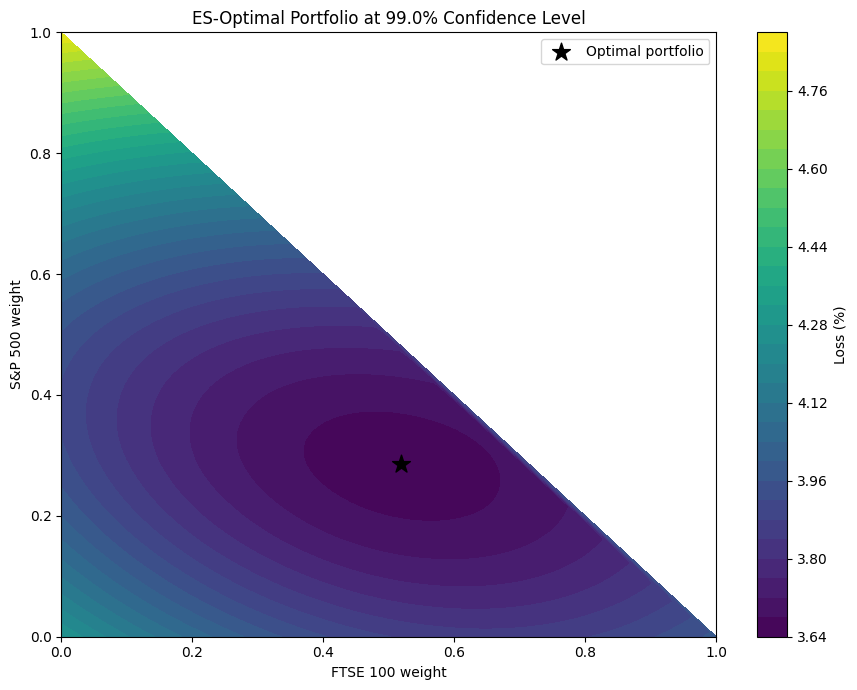

Optimal weights:
FTSE 100:      51.86%
S&P 500:       28.53%
OMX Stockholm: 19.61%
VaR: 2.460%
ES:  3.658%


In [10]:
from scipy.optimize import differential_evolution
from scipy.stats import t, multivariate_t
import numpy as np
import matplotlib.pyplot as plt

def simulate_joint_returns(results_df, copula_results, N=1_000_000):
    np.random.seed(1)

    mu = results_df["t mu"].values
    sigma = results_df["t sigma"].values
    df_marg = results_df["t df"].values

    nu = copula_results["t"]["nu"]
    R = copula_results["t"]["R"]

    Z = multivariate_t.rvs(loc=np.zeros(3), shape=R, df=nu, size=N)
    U = t.cdf(Z, df=nu)

    R_sim = np.zeros_like(U)

    for i in range(3):
        R_sim[:, i] = t.ppf(U[:, i], df=df_marg[i], loc=mu[i], scale=sigma[i])

    return R_sim

def portfolio_VaR_ES(simulated_returns, w, confidence_level):
    portfolio_returns = simulated_returns @ w
    losses = -portfolio_returns
    VaR = np.quantile(losses, confidence_level)
    ES = losses[losses >= VaR].mean()

    return VaR, ES

def optimize_portfolio(simulated_returns, confidence_level, objective="ES"):
    def objective_function(x):
        w1, w2 = x
        w3 = 1 - w1 - w2
        if w3 < 0:
            return 1e6

        w = np.array([w1, w2, w3])
        VaR, ES = portfolio_VaR_ES(simulated_returns, w, confidence_level)

        if objective == "VaR":
            return VaR
        elif objective == "ES":
            return ES
    result = differential_evolution(objective_function, [(0, 1), (0, 1)], seed=1, polish=True)

    w1, w2 = result.x
    w3 = 1 - w1 - w2
    weights = np.array([w1, w2, w3])

    VaR, ES = portfolio_VaR_ES(simulated_returns, weights, confidence_level)
    return weights, VaR, ES

def plot_risk_surface(simulated_returns, confidence_level=0.99, metric="ES", grid_size=100):
    w1_values = np.linspace(0, 1, grid_size)
    w2_values = np.linspace(0, 1, grid_size)

    w1_list = []
    w2_list = []
    risk_list = []

    for w1 in w1_values:
        for w2 in w2_values:
            w3 = 1 - w1 - w2

            if w3 >= 0:
                w = np.array([w1, w2, w3])
                VaR, ES = portfolio_VaR_ES(simulated_returns, w, confidence_level)

                w1_list.append(w1)
                w2_list.append(w2)

                if metric == "VaR":
                    risk_list.append(VaR * 100)
                elif metric == "ES":
                    risk_list.append(ES * 100)

    w1_list = np.array(w1_list)
    w2_list = np.array(w2_list)
    risk_list = np.array(risk_list)

    weights, VaR_opt, ES_opt = optimize_portfolio(simulated_returns, confidence_level, metric)

    fig, ax = plt.subplots(figsize=(9, 7))
    contour = ax.tricontourf(w1_list, w2_list, risk_list, levels=30)
    plt.colorbar(contour, ax=ax, label="Loss (%)")

    ax.scatter(weights[0], weights[1], marker="*", s=180, color="black", label="Optimal portfolio")
    ax.set_xlabel("FTSE 100 weight")
    ax.set_ylabel("S&P 500 weight")
    ax.set_title(f"{metric}-Optimal Portfolio at {confidence_level*100:.1f}% Confidence Level")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

    plt.tight_layout()
    plt.show()

    print("Optimal weights:")
    print(f"FTSE 100:      {weights[0]*100:.2f}%")
    print(f"S&P 500:       {weights[1]*100:.2f}%")
    print(f"OMX Stockholm: {weights[2]*100:.2f}%")
    print(f"VaR: {VaR_opt*100:.3f}%")
    print(f"ES:  {ES_opt*100:.3f}%")

simulated_returns = simulate_joint_returns(results_df, copula_results)
plot_risk_surface(simulated_returns, 0.99, metric="ES")


Above, we see that, for a confidence level of $α = 95\%$, the optimal portfolio consists of a relatively large allocation to the FTSE 100, and smaller allocations to the S&P 500 and the OMX Stockholm. This result is reasonable, given the parameters that model the marginal distributions of the three indices: the modelled marginal distribution of the S&P 500 has the lowest number of degrees of freedom of the three indices, so it has the heaviest tails, and thus has more days with very low returns than the two other indices. The marginal distribution of the OMX Stockholm, on the other hand, has the highest value of the scale factor $σ$, suggesting it has a high variance, and a larger likelihood of days with a very low return. These observations explain the relatively small allocation to these two indices, compared to the FTSE 100. However, varying the value of the confidence level ought to alter the composition of the optimal portfolio: as the confidence level increases, the frequency of large outliers becomes more important relatively to the variance of the distribution. Thus, for high values of the confidence level, such as the $99.9\%$-ES, the allocation to the S&P 500 will likely be lower than for lower values of the confidence level. Conversely, the OMX Stockholm, which has the highest number of degrees of freedom, and thus the least heavy tails, is expected to be allocated more money as the confidence level increases. To see whether this is the case, we determine the optimal weights, seen to minimizing the Expected Shortfall, for different values of the confidence level in the graph below.

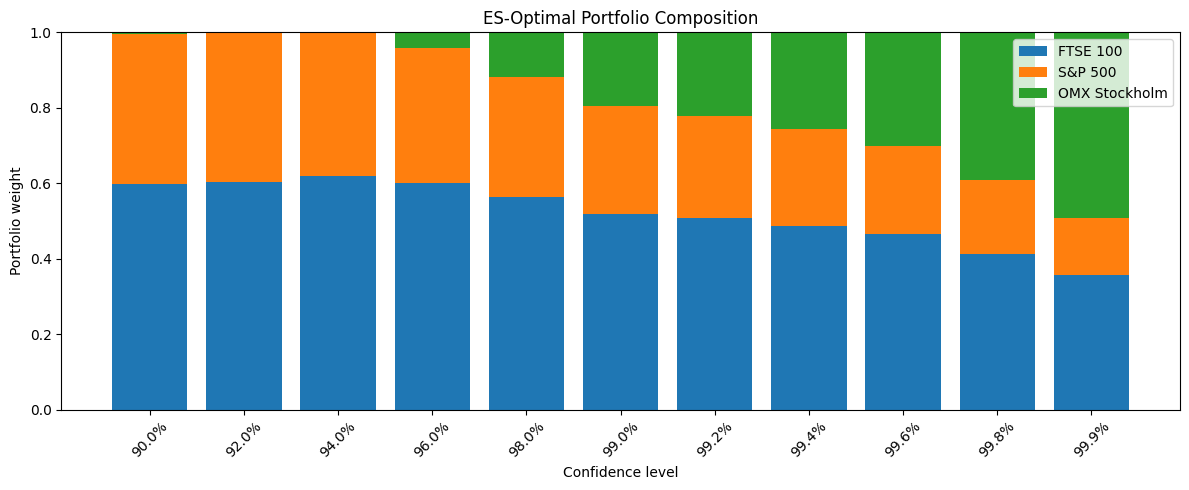

In [11]:
def optimal_weights_by_confidence(simulated_returns, tail_probabilities):
    ES_weights = []
    for p in tail_probabilities:
        confidence_level = 1 - p
        weights_ES, _, _ = optimize_portfolio(simulated_returns, confidence_level, objective="ES")
        ES_weights.append(weights_ES)

    return np.array(ES_weights)

def plot_optimal_weights_by_confidence(simulated_returns, tail_probabilities):
    ES_weights = optimal_weights_by_confidence(simulated_returns, tail_probabilities)
    confidence_levels = [0] * len(tail_probabilities)
    for i in range(len(tail_probabilities)):
        confidence_levels[i] = 1 - tail_probabilities[i]
    confidence_levels = np.array(confidence_levels)
    x = np.arange(len(confidence_levels))

    names = ["FTSE 100", "S&P 500", "OMX Stockholm"]
    fig, ax = plt.subplots(figsize=(12, 5))

    # ES-optimal portfolios
    ax.bar(x, ES_weights[:, 0], label=names[0])
    ax.bar(x, ES_weights[:, 1], bottom=ES_weights[:, 0], label=names[1])
    ax.bar(x, ES_weights[:, 2], bottom=ES_weights[:, 0] + ES_weights[:, 1], label=names[2])

    ax.set_ylabel("Portfolio weight")
    ax.set_xlabel("Confidence level")
    ax.set_title("ES-Optimal Portfolio Composition")
    ax.set_ylim(0, 1)
    ax.legend()

    ax.set_xticks(x)
    ax.set_xticklabels([f"{c*100:.1f}%" for c in confidence_levels], rotation=45)

    plt.tight_layout()
    plt.show()

tail_probabilities = [0.1, 0.08, 0.06, 0.04, 0.02, 0.01, 0.008, 0.006, 0.004, 0.002, 0.001]
plot_optimal_weights_by_confidence(simulated_returns, tail_probabilities)

### Expected Shortfall and Expected Returns
As explained above, we see the expected phenomenon: as the confidence level increases, the allocation to the S&P 500 decreases, while the allocation to the OMX Stockholm increases. While minimizing the Expected Shortfall is a reasonable goal, portfolio management often involves a desire to maximize the expected return of the portfolio. To see the impact of this, we below optimize the portfolio below, by minimizing its Expected Shortfall, subject to different constraints on the portfolio's expected return. Hence, as the minimum expected return increases, the allocation to the index with the highest average return of the three - the S&P 500 - will increase. The S&P 500 was the index with the smallest allocation for high values of the confidence level, in the graph above, illustrating the tradeoff between risk and return.

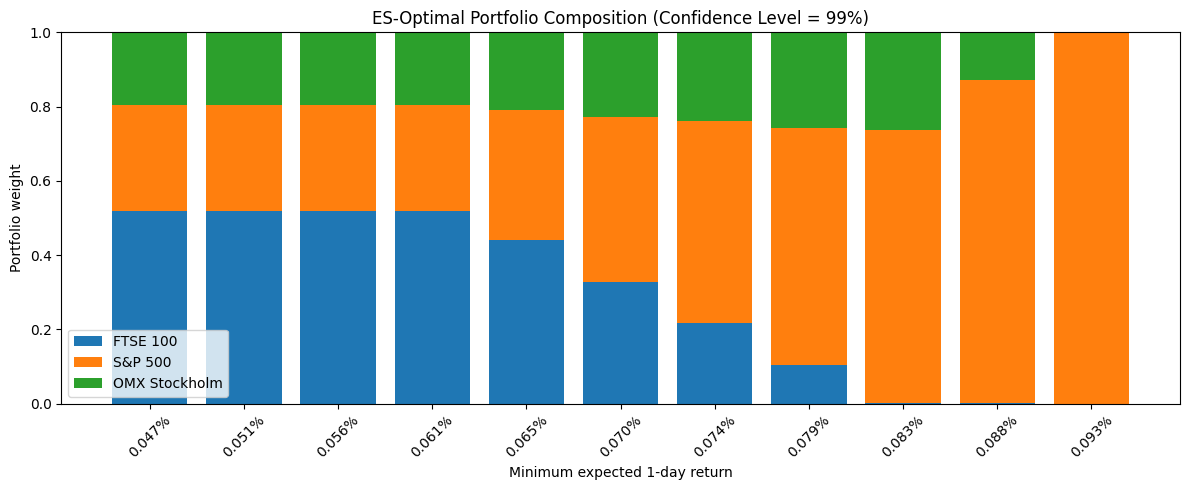

In [12]:
import numpy as np
from scipy.optimize import differential_evolution, LinearConstraint

def optimize_portfolio_min_ES_return(simulated_returns, confidence_level, min_return):
    mu = results_df["t mu"].values

    def objective_function(x):
        w1, w2 = x
        w3 = 1 - w1 - w2
        w = np.array([w1, w2, w3])

        _, ES = portfolio_VaR_ES(simulated_returns, w, confidence_level)

        return ES

    # Since w3 = 1 - w1 - w2,
    # w3 >= 0  <=>  w1 + w2 <= 1
    weight_constraint = LinearConstraint([1, 1], -np.inf, 1)

    # Expected return:
    # w1*mu[0] + w2*mu[1] + w3*mu[2] >= min_return
    # = mu[2] + w1*(mu[0]-mu[2]) + w2*(mu[1]-mu[2])
    return_constraint = LinearConstraint([mu[0] - mu[2], mu[1] - mu[2]], min_return - mu[2], np.inf)

    result = differential_evolution(objective_function, [(0, 1), (0, 1)], constraints=[weight_constraint, return_constraint], seed=1, polish=True)
    w1, w2 = result.x
    w3 = 1 - w1 - w2

    weights = np.array([w1, w2, w3])
    VaR, ES = portfolio_VaR_ES(simulated_returns, weights, confidence_level)
    expected_return = np.dot(weights, mu)

    return weights, expected_return, VaR, ES

def plot_optimal_weights_by_min_return(simulated_returns, confidence_level, min_returns):
    results = []

    for min_return in min_returns:
        weights, expected_return, VaR, ES = optimize_portfolio_min_ES_return(simulated_returns, confidence_level, min_return)
        results.append(weights)

    weights = np.array(results)
    x = np.arange(len(min_returns))
    names = ["FTSE 100", "S&P 500", "OMX Stockholm"]

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.bar(x, weights[:, 0], label=names[0])
    ax.bar(x, weights[:, 1], bottom=weights[:, 0], label=names[1])
    ax.bar(x, weights[:, 2], bottom=weights[:, 0] + weights[:, 1], label=names[2])

    ax.set_ylabel("Portfolio weight")
    ax.set_xlabel("Minimum expected 1-day return")
    ax.set_title(f"ES-Optimal Portfolio Composition " f"(Confidence Level = {confidence_level:.0%})")
    ax.set_ylim(0, 1)
    ax.legend()

    ax.set_xticks(x)
    ax.set_xticklabels([f"{r*100:.3f}%" for r in min_returns], rotation=45)

    plt.tight_layout()
    plt.show()

mu = results_df["t mu"].values
plot_optimal_weights_by_min_return(simulated_returns, confidence_level=0.99, min_returns=np.linspace(mu.min(), mu.max(), 11))

The chart above shows the optimal portfolios under constraints on the expected return, where the minimum expected return ranges from the lowest expected return of the three indices (that of the FTSE 100) to the highest (the S&P 500).
We see that the optimal portfolio for the first few portfolios are all the same, since for these  values of the minimum expected return, the optimal portfolio without constraints on the expected return satisfied the constraints on the expected return. The first few portfolios are the same as what is seen in the previous graph at the corresponding confidence level, in this case $α=95\%$. As the minimum expected return increases, however, more and more of the portfolio needs to be allocated to the S&P 500 to meed the requirement on the expected return. The highest minmum expected return is that of the S&P 500, so the last portfolio thus needs to allocate all its capital to that index in order to fulfil the constraint on the expected return.